In [43]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [ ]:
#根据带有噪声的线性模型构造一个人造数据集。我们使用线形模型参数w=[2, 3.4]^T、b=4.2和噪声项epsilon生成数据集及其标签

def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b # 矩阵乘法
    y += torch.normal(0, 0.01, y.shape) # 加噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [45]:
print('features:', features[0], '\nlabels:', labels[0])

features: tensor([ 1.3503, -1.0235]) 
labels: tensor([10.3800])


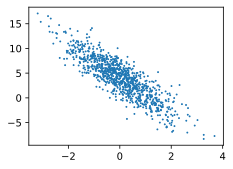

In [ ]:
d2l.set_figsize() #设置画布
d2l.plt.scatter(features[: , 1].detach().numpy(),
                labels.detach().numpy(), 1)

In [47]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    #这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
        
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.2164, -0.4016],
        [-1.8569,  1.2327],
        [-0.9937, -0.1235],
        [-1.1307,  0.9620],
        [-0.3632,  0.7697],
        [-1.8901,  0.6895],
        [-0.5857,  0.7877],
        [ 0.9740,  0.1854],
        [ 0.6279,  0.3666],
        [ 1.5366,  0.6568]]) 
 tensor([[ 5.9878],
        [-3.7049],
        [ 2.6313],
        [-1.3202],
        [ 0.8456],
        [-1.9142],
        [ 0.3609],
        [ 5.5264],
        [ 4.1902],
        [ 5.0345]])


In [48]:
# 定义初始化参数
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [49]:
# 定义模型
def linreg(X, w, b):
    '''线性回归模型'''
    return torch.matmul(X, w) + b

In [50]:
# 定义损失函数
def squared_loss(y_hat, y):
    '''均方损失'''
    return(y_hat - y.reshape(y_hat.shape))**2 / 2

In [51]:
# 定义优化算法
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_() 

In [52]:
# 开始训练
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # 'X'和'y'的小批量损失
        # 因此'1'形状是('batch_size', 1)，而不是一个标量。'l'中的所有元素被加到一起求和得到单个目标损失值
        # 并以此计算关于['w', 'b']的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size) # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.043742
epoch 2, loss 0.000180
epoch 3, loss 0.000050


In [53]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 0.0006, -0.0002], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0005], grad_fn=<RsubBackward1>)
